<div align="center">

# <span style="color: #3498db;">CA2 - Genetic & Game Q1</span>

**<span style="color:rgb(247, 169, 0);">[Mohammad Hossein Mazaheri]</span> - <span style="color:rgb(143, 95, 195);">[810102585]</span>**

</div>


<div style="font-family: Arial, sans-serif; line-height: 1.6;">

### 📊 Matplotlib – Data Visualization in Python  

matplotlib is a python library that is mainly used for data visualization. This library allows you to plot different type of figures including scatters and histograms. In the first part of this project you are supposed to implement a genetic algorithm. To visualize plots that are required in the project description use plotting as much as you can because it gives a great insight on what is happening during each run. It also helps you to compare your results whenevever you want to understand effect of different parameters during different runs.
For more information, check [this notebook](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.00-Introduction-To-Matplotlib.ipynb) and visit [the website](https://matplotlib.org/stable/tutorials/pyplot.html#sphx-glr-tutorials-pyplot-py).

In [69]:
import matplotlib.pyplot as plt

# <span style="color: #3498db;">Genetic Algorithm</span>

In [70]:
import random
import itertools
import numpy as np
from enum import Enum  
from scipy.integrate import quad
import copy

In [71]:
gen_num = 250
population_size = 100
mutation_rate = 0.2
num_one_coeffs = 20
func_range = (-np.pi, np.pi)
cof_range = 10
func_name = "sin_cos"
fitness_type = "huber"
selection_type = "tournament"
crossover_type = "uniform"
t_sample = np.linspace(func_range[0], func_range[1], population_size)

In [72]:
# These functions are given as samples to use in the algorithm
def getTargetFunction(functionName="sin_cos"):
    def sinCosFunction(t):
        """Target function: sin(2πt) + 0.5*cos(4πt)."""
        return np.sin(2 * np.pi * t) + 0.5 * np.cos(4 * np.pi * t)

    def linearFunction(t):
        """Simple linear function: y = 2t + 1."""
        return 2 * t + 1

    def quadraticFunction(t):
        """Quadratic function: y = 4t^2 - 4t + 2."""
        return 4 * (t**2) - 4 * t + 2

    def cubicFunction(t):
        """Cubic function: y = 8t^3 - 12t^2 + 6t."""
        return 8 * (t**3) - 12 * (t**2) + 6 * t

    def gaussianFunction(t):
        """Gaussian function centered at t=0.5."""
        mu = 0.5
        sigma = 0.1  # Adjust sigma to control the width of the peak
        return np.exp(-((t - mu) ** 2) / (2 * sigma**2))

    def squareWaveFunction(t):
        """Approximation of a square wave. Smoothed for better Fourier approximation."""
        return 0.5 * (np.sign(np.sin(2 * np.pi * t)) + 1)

    def sawtoothFunction(t):
        """Sawtooth wave, normalized to [0, 1]."""
        return (t * 5) % 1

    def complexFourierFunction(t):
        return (
            np.sin(2 * np.pi * t)
            + 0.3 * np.cos(4 * np.pi * t)
            + 0.2 * np.sin(6 * np.pi * t)
            + 0.1 * np.cos(8 * np.pi * t)
        )

    def polynomialFunction(t):
        return 10 * (t**5) - 20 * (t**4) + 15 * (t**3) - 4 * (t**2) + t + 0.5

    functionOptions = {
        "sin_cos": sinCosFunction,
        "linear": linearFunction,
        "quadratic": quadraticFunction,
        "cubic": cubicFunction,
        "gaussian": gaussianFunction,
        "square_wave": squareWaveFunction,
        "sawtooth": sawtoothFunction,
        "complex_fourier": complexFourierFunction,
        "polynomial": polynomialFunction,
    }

    selectedFunction = functionOptions.get(functionName.lower())
    if selectedFunction:
        return selectedFunction

<div style="color:rgb(235, 66, 32); font-weight: bold;">⚠️ Important Note:</div>  

Using **NumPy arrays** allows you to perform operations on vectors **more efficiently** and **faster**.

**Avoid using `for` loops** whenever possible, as vectorized operations in NumPy are **optimized for performance** and significantly reduce execution time.  


In [73]:
def fourier_calculation(function_name="a_0"):
    def calculate_a_0(f_x):
            func = getTargetFunction(f_x)
            integral, _ = quad(func, -np.pi, np.pi)
            return integral / np.pi
    
    def calculate_a_n(f_x, n):
        func = getTargetFunction(f_x)
        integral, _ = quad(lambda x: func(x) * np.cos(n * x), -np.pi, np.pi)
        return integral / np.pi
    
    def calculate_b_n(f_x, n):
        func = getTargetFunction(f_x)
        integral, _ = quad(lambda x: func(x) * np.sin(n * x), -np.pi, np.pi)
        return integral / np.pi
    
    def fourier_result(a_0, array_a, array_b, t):
        n_terms = np.arange(1, len(array_a) + 1)
        
        return (a_0 / 2 + 
                np.sum(array_a * np.cos(n_terms * t[:, None]), axis=1) + 
                np.sum(array_b * np.sin(n_terms * t[:, None]), axis=1))

    function_options = {
        "a_0" : calculate_a_0,
        "a_n" : calculate_a_n,
        "b_n" : calculate_b_n,
        "fourier_ans" : fourier_result
    }

    selected_function = function_options.get(function_name.lower())
    if selected_function:
        return selected_function

## generate chromosome

In [74]:
class Chromosome:
    def __init__(self):
        self._genes = np.random.uniform(low=-cof_range, high=cof_range, size=2*num_one_coeffs+1)
        self._fitness = float()
        self._rank = int()
        self.update_fitness(fitness_type)
    
    @property
    def genes(self):
        return self._genes.copy()
    
    @genes.setter
    def genes(self, values):
        if len(values) == 2*num_one_coeffs+1:
            self._genes = np.array(values, dtype=np.float64)
            self.update_fitness(fitness_type)
            

    @property
    def rank(self):
        return self._rank
    
    @rank.setter
    def rank(self, value):
        self._rank = value
 
    def get_a_0(self):
        return self.genes[0]

    def get_a_n(self):
        return self.genes[1:num_one_coeffs+1].copy()

    def get_b_n(self):
        return self.genes[num_one_coeffs+1:2*num_one_coeffs+1].copy()
    
    def get_fitness(self):
        return self._fitness

    def update_fitness(self, function_name="rmse"):
        fourier_f_x = fourier_calculation("fourier_ans")(
            a_0=self.get_a_0(),
            array_a=self.get_a_n(),
            array_b=self.get_b_n(),
            t=t_sample
        )
        real_f_x = getTargetFunction(func_name)(t_sample)

        def rmse():
            error = np.sqrt(np.mean((real_f_x - fourier_f_x) ** 2))
            return 1 / (error + 1e-8)

        def mae():
            error = np.mean(np.abs(real_f_x - fourier_f_x))
            return 1 / (error + 1e-8)

        def huber(delta=1.0):
            error = real_f_x - fourier_f_x
            is_small_error = np.abs(error) <= delta
            squared_loss = 0.5 * (error ** 2)
            linear_loss = delta * (np.abs(error) - 0.5 * delta)
            loss = np.where(is_small_error, squared_loss, linear_loss)
            return 1 / (np.mean(loss) + 1e-8)

        

        function_options = {
            "rmse": rmse,
            "mae": mae,
            "huber": huber
        }

        selected_function = function_options.get(function_name.lower())
        if selected_function:
            self._fitness = selected_function()


In [75]:
def select_parents(selection="tournament", k=8):
    def tournament_selection(generation):
        random_idx = np.random.choice(population_size, k)
        sorted_idx = sorted(random_idx, key=lambda idx: generation[idx].get_fitness(), reverse=True)

        return generation[sorted_idx[0]], generation[sorted_idx[1]]
    

    def roulette_wheel_selection(generation):
        fitnesses = np.array([ind.get_fitness() for ind in generation])
        total_fitness = np.sum(fitnesses)
        probabilities = fitnesses / total_fitness

        selected = np.random.choice(generation, size=2, replace=False, p=probabilities)
        return selected[0], selected[1]
    
    
    def rank_based_selection(generation):
        fitnesses = np.array([ind.get_fitness() for ind in generation])
        ranks = np.argsort(np.argsort(fitnesses))
        probabilities = (ranks + 1) / np.sum(ranks + 1)
        
        selected = np.random.choice(generation, size=2, replace=False, p=probabilities)
        return selected[0], selected[1]
    


    function_options = {
        "tournament": tournament_selection,
        "roulette_wheel": roulette_wheel_selection,
        "rank_based": rank_based_selection
    }

    selected_function = function_options.get(selection.lower())
    if selected_function:
        return selected_function

In [76]:
def crossover(crossover="single_point"):
    def single_point_crossover(p1, p2):
        point = np.random.randint(1, len(p1.genes))
        child1_genes = np.concatenate((p1.genes[:point], p2.genes[point:]))
        child2_genes = np.concatenate((p2.genes[:point], p1.genes[point:]))

        chrom1 = Chromosome()
        chrom1.genes = child1_genes
        chrom2 = Chromosome()
        chrom2.genes = child2_genes
        return chrom1, chrom2


    def uniform_crossover(p1, p2):
        mask = np.random.randint(0, 2, len(p1.genes)).astype(bool)
        child1_genes = np.where(mask, p1.genes, p2.genes)
        child2_genes = np.where(mask, p2.genes, p1.genes)
        
        chrom1 = Chromosome()
        chrom1.genes = child1_genes
        chrom2 = Chromosome()
        chrom2.genes = child2_genes
        return chrom1, chrom2
    
    def multipoint_crossover(p1, p2, num_points=5):
        points = sorted(np.random.choice(range(1, 2*num_one_coeffs+1), size=num_points, replace=False))
        points = [0] + points + [2*num_one_coeffs+1]
        child1_genes = []
        child2_genes = []

        for i in range(len(points) - 1):
            start, end = points[i], points[i+1]
            if i % 2 == 0:
                child1_genes.extend(p1.genes[start:end])
                child2_genes.extend(p2.genes[start:end])
            else:
                child1_genes.extend(p2.genes[start:end])
                child2_genes.extend(p1.genes[start:end])

        chrom1 = Chromosome()
        chrom1.genes = child1_genes
        chrom2 = Chromosome()
        chrom2.genes = child2_genes
        return chrom1, chrom2


    function_options = {
        "single_point": single_point_crossover,
        "uniform": uniform_crossover,
        "multipoint": multipoint_crossover
    }

    selected_function = function_options.get(crossover.lower())
    if selected_function:
        return selected_function

In [77]:
def mutate(chromosome):
    mutated = chromosome.genes.copy()
    for i in range(len(mutated)):
        if np.random.rand() < mutation_rate:
            mutated[i] += np.random.uniform(-0.3, 0.3)
    mutated = np.clip(mutated, -10, 10)
    chromosome.genes = mutated
    return chromosome

## make population

In [78]:
class History:
    class Generation:
        def __init__(self):
            self._chromosomes = np.array([], dtype=object)

        @property
        def chromosomes(self):
            return self._chromosomes.copy()

        @chromosomes.setter
        def chromosomes(self, value):
            if isinstance(value, np.ndarray):
                self._chromosomes = value
            else:
                raise TypeError("chromosomes must be a numpy ndarray")

        def init_sample(self):
            if self._chromosomes.size == 0:
                self._chromosomes = np.array([Chromosome() for _ in range(population_size)])
            else:
                raise ValueError("Population already initialized")
        
        def evolve(self):
            new_population = np.array([], dtype=object)

            while len(new_population) < population_size:
                parent1, parent2 = select_parents(selection=selection_type)(self.chromosomes)
                child1, child2 = crossover(crossover=crossover_type)(parent1, parent2)

                child1 = mutate(child1)
                child2 = mutate(child2)

                new_population = np.append(new_population, child1)
                new_population = np.append(new_population, child2)

            self._chromosomes = new_population


            
    def __init__(self):
        self._generations = [self.Generation()]
        self._generation_lev = 0

    @property
    def generations(self):
        return self._generations

    @generations.setter
    def generation(self, value):
        if isinstance(value, np.ndarray):
            self._generations = value
        else:
            raise TypeError("chromosomes must be a numpy ndarray")
    
    def clear_history(self):
        self._generations = [self.generations[0]]
        self._generation_lev = 0

    def pass_time(self):
        evolved = History.Generation()
        evolved.chromosomes = self.generations[self._generation_lev].chromosomes.copy()
        evolved.evolve()
        self.generations.append(evolved)

        self._generation_lev += 1

In [79]:
def plot_population_comparison(population_sizes, generations_history):
    plt.figure(figsize=(10, 6))
    for size, history in zip(population_sizes, generations_history):
        fitness_progress = [
            max(chromo.get_fitness() for chromo in gen.chromosomes)
            for gen in history.generations
        ]
        plt.plot(fitness_progress, label=f"Pop size {size}")
    plt.title("Fitness over Generations (Population Size Comparison)")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(True)
    plt.show()

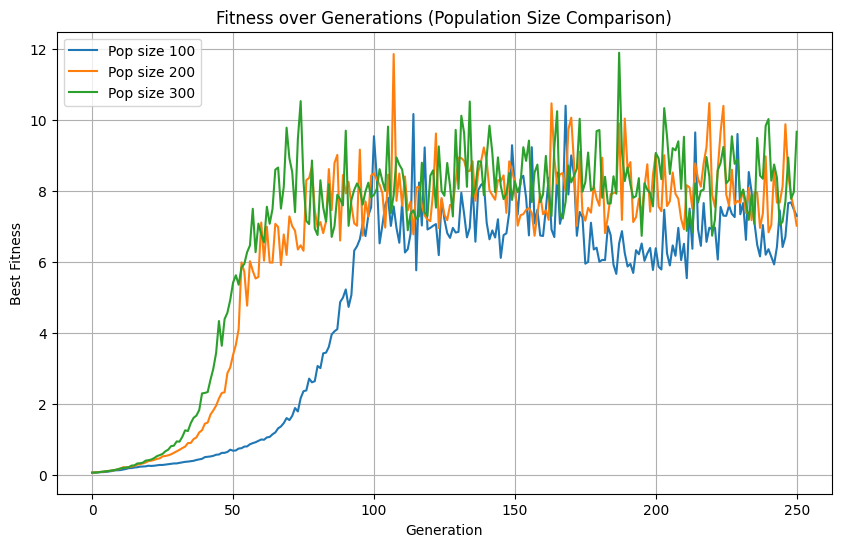

In [80]:
population_sizes = [100, 200, 300]
generations_history = []

for pop_size in population_sizes:
    population_size = pop_size
    hist = History()
    hist.generations[0].init_sample()
    for _ in range(gen_num):
        hist.pass_time()
    generations_history.append(hist)

population_size = 200
plot_population_comparison(population_sizes, generations_history)

In [81]:
def plot_crossover_comparison(crossover_methods, generations_history):
    plt.figure(figsize=(10, 6))
    for method, history in zip(crossover_methods, generations_history):
        fitness_progress = [
            max(chromo.get_fitness() for chromo in gen.chromosomes)
            for gen in history.generations
        ]
        plt.plot(fitness_progress, label=f"{method}")
    plt.title("Fitness over Generations (Crossover Comparison)")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(True)
    plt.show()

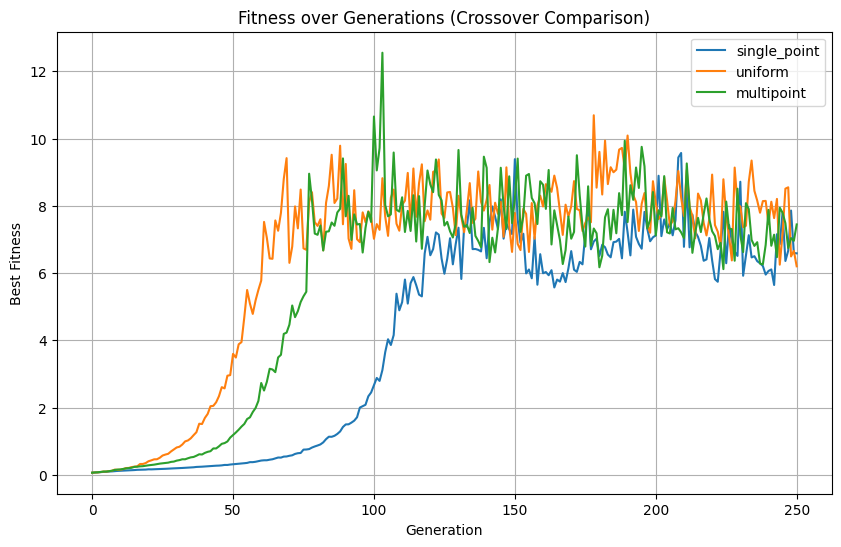

In [82]:
crossover_methods = ["single_point", "uniform", "multipoint"]
generations_history = []

hist = History()
hist.generations[0].init_sample()
for method in crossover_methods:
    crossover_type = method
    for _ in range(gen_num):
        hist.pass_time()
    generations_history.append(copy.deepcopy(hist))
    hist.clear_history()

crossover_type = "uniform"
plot_crossover_comparison(crossover_methods, generations_history)

In [83]:
def plot_selection_comparison(selection_methods, generations_history):
    plt.figure(figsize=(10, 6))
    for method, history in zip(selection_methods, generations_history):
        fitness_progress = [
            max(chromo.get_fitness() for chromo in gen.chromosomes)
            for gen in history.generations
        ]
        plt.plot(fitness_progress, label=f"{method}")
    plt.title("Fitness over Generations (Selection Method Comparison)")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(True)
    plt.show()

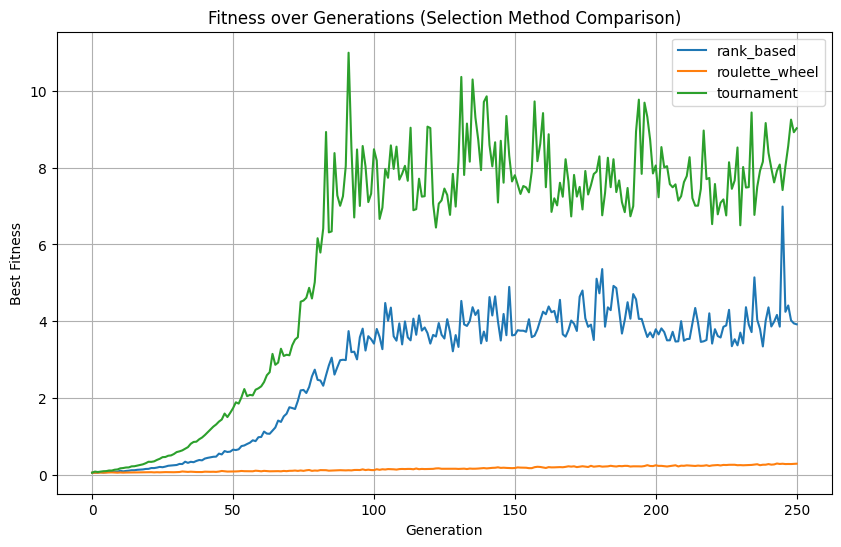

In [84]:
selection_methods = ["rank_based", "roulette_wheel", "tournament"]

generations_history = []

hist = History()
hist.generations[0].init_sample()
for method in selection_methods:
    selection_type = method

    for _ in range(gen_num):
        hist.pass_time()

    generations_history.append(copy.deepcopy(hist))
    hist.clear_history()
    
plot_selection_comparison(selection_methods, generations_history)

In [85]:
def plot_eval_method_comparison(eval_methods, generations_history):
    plt.figure(figsize=(10, 6))
    for method, history in zip(eval_methods, generations_history):
        fitness_progress = [
            max(chromo.get_fitness() for chromo in gen.chromosomes)
            for gen in history.generations
        ]
        plt.plot(fitness_progress, label=f"{method.upper()}")
    plt.title("Fitness over Generations (Evaluation Method Comparison)")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(True)
    plt.show()

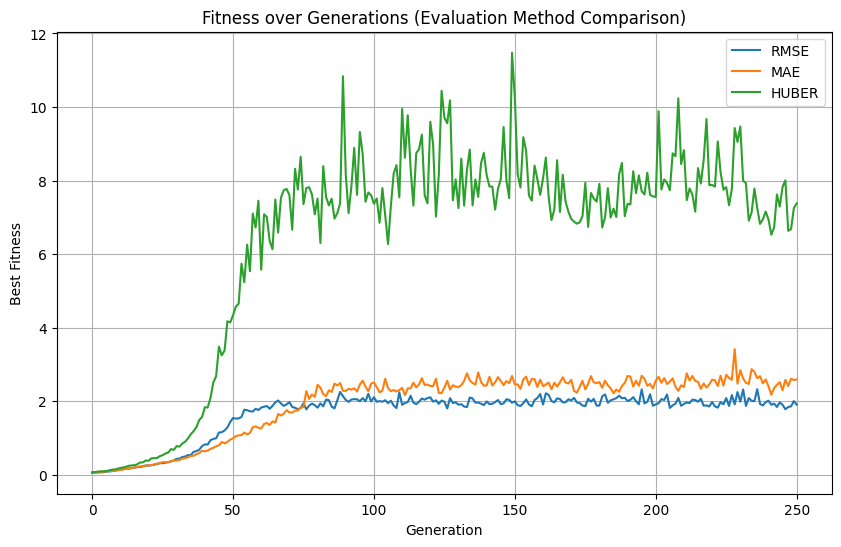

In [86]:
eval_methods = ["rmse", "mae", "huber"]
generations_history = []

for method in eval_methods:
    fitness_type = method  # Set global or shared config
    hist = History()
    hist.generations[0].init_sample()

    for _ in range(gen_num):
        hist.pass_time()

    generations_history.append(copy.deepcopy(hist))

plot_eval_method_comparison(eval_methods, generations_history)


In [87]:
def plot_target_vs_fourier(best_chromosome):
    t = t_sample
    real_y = getTargetFunction(func_name)(t)
    fourier_y = fourier_calculation("fourier_ans")(
        a_0=best_chromosome.get_a_0(),
        array_a=best_chromosome.get_a_n(),
        array_b=best_chromosome.get_b_n(),
        t=t
    )

    plt.figure(figsize=(10, 6))
    plt.plot(t, real_y, label="Target Function", linewidth=2)
    plt.plot(t, fourier_y, label="Fourier Approximation", linestyle='--')
    plt.title("Function Approximation using Fourier Series")
    plt.xlabel("t")
    plt.ylabel("f(t)")
    plt.legend()
    plt.grid(True)
    plt.show()


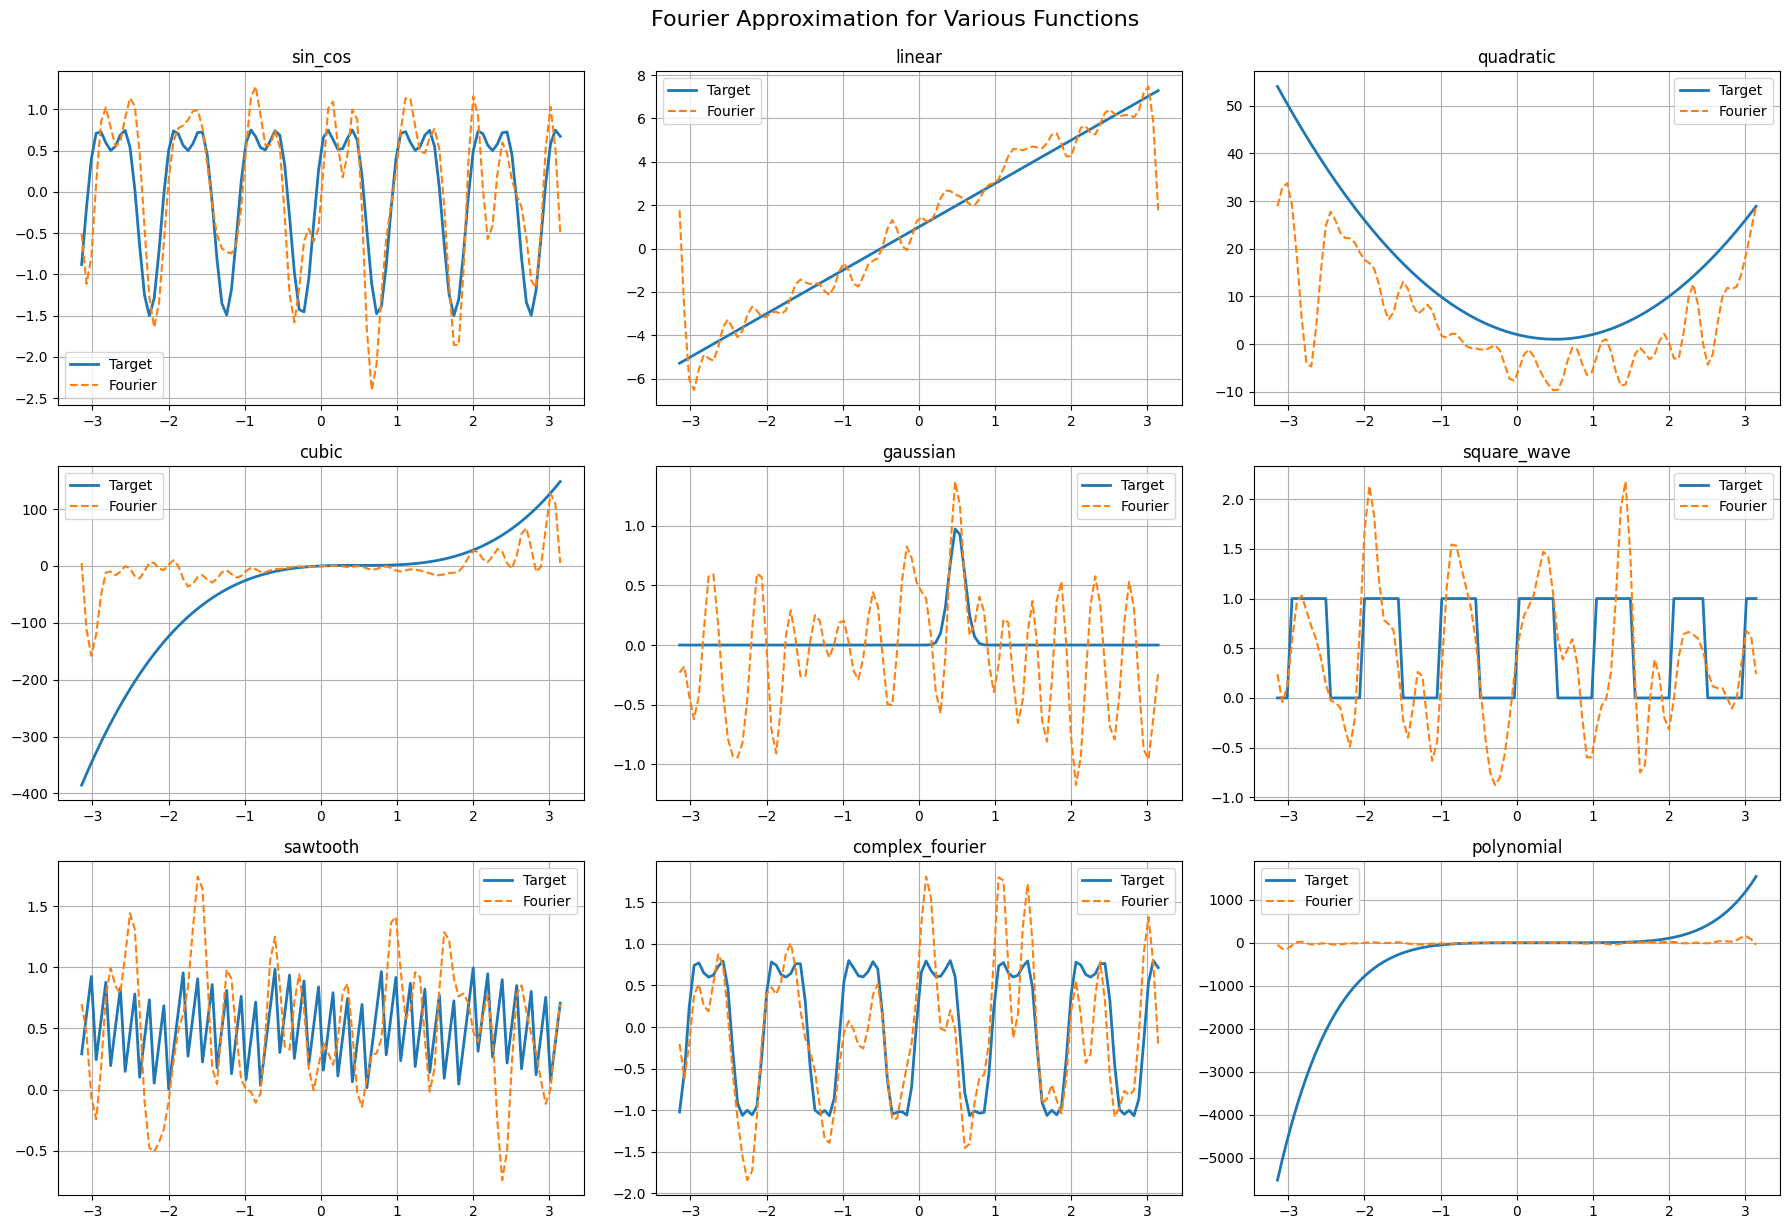

In [88]:
func_names = ["sin_cos", "linear", "quadratic", "cubic", "gaussian", "square_wave", "sawtooth", "complex_fourier", "polynomial"]
fitness_type = "huber"
selection_type = "tournament"
crossover_type = "uniform"
population_size = 200
gen_num = 250

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()  # Make it easy to loop

for i, name in enumerate(func_names):
    func_name = name
    hist = History()
    hist.generations[0].init_sample()

    for _ in range(gen_num):
        hist.pass_time()

    final_generation = hist.generations[-1]
    best_chromosome = max(final_generation.chromosomes, key=lambda c: c.get_fitness())

    t = t_sample
    real_y = getTargetFunction(func_name)(t)
    fourier_y = fourier_calculation("fourier_ans")(
        a_0=best_chromosome.get_a_0(),
        array_a=best_chromosome.get_a_n(),
        array_b=best_chromosome.get_b_n(),
        t=t
    )

    ax = axes[i]
    ax.plot(t, real_y, label="Target", linewidth=2)
    ax.plot(t, fourier_y, label="Fourier", linestyle='--')
    ax.set_title(func_name)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.suptitle("Fourier Approximation for Various Functions", fontsize=16, y=1.02)
plt.show()
